## Futásidő-összevetés: rprev referencia (naiv K-szoros) vs. kiterjesztett több indexdátumos implementáció

*Készült: 2026. március 9.*  
*Szerző: Radó László*

Ez a notebook a **„A Crouch-féle szimulációs prevalencia-becslés kiterjesztése folytonos időbeli modellezésre”** című szakdolgozat validációs anyaga.  
A dolgozat a Crouch-féle incidencia–túlélés alapú Monte Carlo szimulációs prevalenciabecslés elméleti keretére és az R csomagként telepíthető `rprev` referencia-implementációra épül. A központi feladat a referencia-eljárás több indexdátum együttes kezelésére szolgáló kiterjesztése, valamint ennek módszertani és numerikus validálása (lásd: dolgozat 3–5. fejezet).

A referencia csomag dokumentációja: https://cloud.r-project.org/web/packages/rprev/

A fentieknek megfelelően a **referencia** implementáció definíció szerint egyetlen indexdátumhoz ad prevalencia-becslést, ezért több indexdátum esetén az eredmény az rprev `prevalence()` függvényének többszörös egy-indexű függvényhívásainak sorozatából állítható elő. A **kiterjesztett implementáció** ezzel szemben több indexdátum együttes kezelésére készült, és a teljes indexrácsra konzisztens becslést ad egy közös futási keretben (lásd: 4. fejezet – referencia implementáció és a kiterjesztés tárgya; 5. fejezet – matematikai modell és csomagszintű illesztés).

### Validációs cél

Ez a notebook a dolgozat 4.3 - 4.7 szakaszában rögzített futásidő-összevetési protokoll empirikus megvalósítása. A vizsgálat célja annak számszerűsítése, hogy azonos bemeneti adatok és azonos szimulációs beállítások mellett mekkora számítási többletet jelent a referencia-megoldás indexdátumonkénti, egyindexű futtatássorozata a natív többindexű kiterjesztéshez képest.

A dolgozat terminológiáját követve a referencia-megoldás egy eljárásfuttatás során a $\{t_k\}_{k=1}^K$ rács kimenetét $K$ darab alapkiértékeléssel állítja elő, míg a kiterjesztett implementáció ugyanezt a kimeneti objektumot egyetlen eljárásfuttatásból adja vissza. Ennek megfelelően a referencia-megoldásban az incidencia- és túlélési komponens illesztése, valamint a hozzájuk kapcsolódó szimuláció minden indexdátumra újra lefut (lásd 3.5 fejezet), míg a natív többindexű eljárás ezeket egyszer állítja elő, és ugyanebből a közös futási keretből nyeri ki a több időpontra vonatkozó kimenetet (lásd 5. fejezet). A futásidő összevetése ezért nem egyetlen `prevalence()` hívás, hanem a teljes rács kimenetének előállítási költsége szintjén történik.

### Mérési protokoll

Mindkét eljárást azonos futtatási környezetben, azonos paraméterezés mellett ismételjük meg. Egy mérési ismétlésben a referencia-megoldás teljes futásideje a $K$ külön `prevalence()` hívás eltelt idejének összege, míg a kiterjesztett megoldásé az egyetlen többindexű `prevalence()` hívás eltelt ideje. A notebook minden paraméterpontra öt független mérési ismétlést végez, az időeredményeket a `system.time(...)[["elapsed"]]` alapján rögzíti, és az értékeléshez ezek átlagát használja.

A kiterjesztés által elért gyorsulást gyorsulási tényezőként adjuk meg:

$$
G(N,K,N_{\mathrm{sim}})=
\frac{\overline{T}_{\mathrm{ref}}(N,K,N_{\mathrm{sim}})}{\overline{T}_{\mathrm{ext}}(N,K,N_{\mathrm{sim}})},
$$

ahol $\overline{T}_{\mathrm{ref}}$ a referencia-megoldás ismétlésekre vett átlagos összfutásideje, $\overline{T}_{\mathrm{ext}}$ pedig a kiterjesztett eljárás ismétlésekre vett átlagos futásideje.

### Bemeneti adat és paraméterezés

A méréshez az `rprev` csomag `prevsim` példaadata szolgál alapul. Ebből visszatevéses mintavétellel állítjuk elő az $N$ soros bemeneti táblát, hogy a számítási terhelés skálázódását kontrollált módon vizsgálhassuk. Az indexdátumok egy rögzített kezdődátumtól (`index_start`) és rögzített naplépéstől (`index_step_days`) képzett, rendezett, $K$ hosszú sorozatot alkotnak, így adott konfiguráció mellett az `index_dates` teljesen reprodukálható.

A mérések rácsa az $N$ adatméret, a $K$ indexdátumszám és az `N_boot` bootstrap ismétlésszám mentén szervezett. A modellformula, az eloszlásválasztás és a további becslési beállítások a mérési pontok között változatlanok maradnak, ezért az egyes futásidők közötti különbségek közvetlenül a vizsgált skálaparaméterekhez rendelhetők.

### Kimenet és értelmezés

A notebook végén előálló összegző tábla minden paraméterpontra tartalmazza az $N$, $K$ és `N_boot` beállításokat, az öt mérési ismétlésből képzett átlagos futásidőket, valamint az ezekből számolt gyorsulási tényezőt. A részletes futási naplók a kódrepozitóriumban elhelyezett notebookban találhatók meg \cite{myrprevRepo}; a dolgozatban ezekből a futásidő-összevetés szempontjából lényegi összegző táblázatokat emeljük be.

---


### Mérési környezet
Az alábbi tábla a futásidőmérésekhez használt aktuális hardver- és szoftverkörnyezet legfontosabb jellemzőit foglalja össze.

In [1]:
# A mérési környezet alapadatainak lekérdezése PowerShell segítségével
ps <- function(cmd) trimws(system2("powershell", c("-NoProfile", "-Command", cmd), stdout = TRUE))[1]

build <- suppressWarnings(as.integer(ps("(Get-ItemProperty 'HKLM:\\SOFTWARE\\Microsoft\\Windows NT\\CurrentVersion').CurrentBuild")))
release <- ps("(Get-ItemProperty 'HKLM:\\SOFTWARE\\Microsoft\\Windows NT\\CurrentVersion').DisplayVersion")
memory_gb <- round(as.numeric(ps("(Get-CimInstance Win32_ComputerSystem).TotalPhysicalMemory")) / 1024^3, 1)

# A futtatási környezet összefoglaló táblázatának összeállítása
runtime_config <- data.frame(
  parameter = c("Mérés ideje", "Operációs rendszer", "OS release", "Géptípus", "CPU", "Logikai magszám", "Fizikai magszám", "Memória (GB)", "R verzió", "R platform"),
  value = c(
    format(Sys.time(), "%Y-%m-%d %H:%M:%S %Z"),
    paste0(if (!is.na(build) && build >= 22000) "Windows 11" else "Windows", " x64 (build ", build, ")"),
    release,
    Sys.info()[["machine"]],
    ps("(Get-CimInstance Win32_Processor | Select-Object -First 1 -ExpandProperty Name)"),
    parallel::detectCores(logical = TRUE),
    parallel::detectCores(logical = FALSE),
    memory_gb,
    R.version.string,
    R.version$platform
  ),
  stringsAsFactors = FALSE
)

runtime_config

parameter,value
<chr>,<chr>
Mérés ideje,2026-03-11 10:47:37 CET
Operációs rendszer,Windows 11 x64 (build 26100)
OS release,24H2
Géptípus,x86-64
CPU,12th Gen Intel(R) Core(TM) i5-1245U
Logikai magszám,12
Fizikai magszám,10
Memória (GB),23.7
R verzió,R version 4.4.2 (2024-10-31 ucrt)


#### 1. Közös paraméter konfiguráció
- A futásidő-mérés paraméterrácsának és a rögzített modellspecifikációs beállításoknak a központi definiálása a reprodukálhatóság érdekében.
- A referencia és a kiterjesztett megoldása futtatása ugyanebből a paraméterkészletből dolgozik, így az összevetés konzisztens.

In [2]:
# COMMON_CFG <- list(
#   # Méretek / rácsparaméterek
#   N_values              = c(1e2, 1e3),        # bemeneti tábla sorszámai (rekordszámok)
#   K_values              = c(1, 5),            # indexdátumok száma (K időpont)
#   N_boot_values         = c(50, 100),         # bootstrap ismétlések száma
#   reps                  = 3L,                 # ismétlések száma paraméterpontonként (átlagolt idő)
#   seed                  = 20260227L,          # közös seed a reprodukálható futtatáshoz
#   num_years_to_estimate = c(20),              # becslési horizont (év)
#   index_start           = as.Date("2013-01-30"), # első indexdátum
#   index_step_days       = 30L,                # indexdátumok lépésköze napokban
#   dist                  = "weibull",          # túlélési eloszlás típusa
#   population_size       = 1e6                 # populációméret a prevalenciához
# )

COMMON_CFG <- list(
  # Méretek / rácsparaméterek
  N_values              = c(1e3, 1e4),        # bemeneti tábla sorszámai (rekordszámok)
  K_values              = c(1, 50),   # indexdátumok száma (K időpont)
  N_boot_values         = c(1000),  # bootstrap ismétlések száma
  reps                  = 3L,                 # ismétlések száma paraméterpontonként (átlagolt idő)
  seed                  = 20260227L,          # közös seed a reprodukálható futtatáshoz
  num_years_to_estimate = c(20),              # becslési horizont (év)
  index_start           = as.Date("2013-01-30"), # első indexdátum
  index_step_days       = 30L,                # indexdátumok lépésköze napokban
  dist                  = "weibull",          # túlélési eloszlás típusa
  population_size       = 1e6                 # populációméret a prevalenciához
)

#### 2. Környezet előkészítése és skálázott bemenetek képzése
- A szükséges csomagok betöltése után a `prevsim` szintetikus példaadat beolvasása.
- A `prevsim` táblából, a konfigurációban megadott `N_values` értékekre visszatevéses mintavétellel több, kontrollált méretű bemeneti tábla készül, melyek egységes alapot biztosítanak a futásidőmérésekhez.
- A konfigurációban megadott `K_values` értékek alapján indexdátum-sorozat készítése a későbbi futtatások egységes paraméterezéséhez.

In [3]:
# Csomagok betöltése
suppressPackageStartupMessages({
  library(rprev)
  library(survival)
})

# Példaadat betöltése (kiinduló tábla)
data(prevsim, package = "rprev")
base_df <- as.data.frame(prevsim)


Warning message:
"package 'rprev' was built under R version 4.4.3"


In [4]:
# Skálázott bemenetek előállítása: minden N-hez egy N soros minta (visszatevéses)
scaled_data <- setNames(
  lapply(COMMON_CFG$N_values, function(N) {
    set.seed(as.integer(COMMON_CFG$seed) + as.integer(N))
    base_df[sample.int(nrow(base_df), size = as.integer(N), replace = TRUE), , drop = FALSE]
  }),
  paste0("N", COMMON_CFG$N_values)
)


In [5]:
# Indexdátumok előállítása
index_dates_by_k <- setNames(
  lapply(COMMON_CFG$K_values, function(K) {
    seq.Date(
      from = COMMON_CFG$index_start,
      by = as.integer(COMMON_CFG$index_step_days),
      length.out = as.integer(K)
    )
  }),
  as.character(COMMON_CFG$K_values)
)

index_dates_chr_by_k <- lapply(index_dates_by_k, format, "%Y-%m-%d")


#### 3. Referencia-megoldás futásidő-mérése: K külön `prevalence()` hívással
- A segédfüggvények által előállított $K$ darab indexdátum alapján a referencia-megoldás $K$ külön hívással elvégzi a prevalencia belést.
- Az időmérés `system.time()` alapján történik, és paraméterpontonként a `reps` számú ismétlésből származó futásidők átlagolásra kerülnek.

In [ ]:
# Referencia-megoldás: prevalence() hívás összeállítása
run_rprev_once <- function(dat, index_date_chr, N_boot) {
  rprev::prevalence(
    index = index_date_chr,
    num_years_to_estimate = COMMON_CFG$num_years_to_estimate,
    data = dat,
    inc_formula  = entrydate ~ sex,
    surv_formula = Surv(time, status) ~ age + sex,
    dist = COMMON_CFG$dist,
    population_size = COMMON_CFG$population_size,
    death_column = "eventdate",
    N_boot = N_boot
  )
}

# Referencia-megoldás: Az összeállított prevalence() függvény K külön hívása, és összidő számítása
measure_one_setting <- function(N, K, N_boot) {
  dat <- scaled_data[[paste0("N", as.integer(N))]]

  idx_dates_chr <- index_dates_chr_by_k[[as.character(K)]]

  if (length(idx_dates_chr) != K || anyNA(idx_dates_chr)) {
    stop("Index dátum generálás hibás: idx_dates_chr NA-t tartalmaz vagy rossz hossz.")
  }

  elapsed <- numeric(COMMON_CFG$reps)
  for (r in seq_len(COMMON_CFG$reps)) {
    gc()
    t <- system.time({
      for (d_chr in idx_dates_chr) {
        invisible(run_rprev_once(dat, d_chr, N_boot))
      }
    })
    elapsed[r] <- unname(t[["elapsed"]])
  }

  res <- data.frame(
    N = N,
    K = K,
    N_boot = N_boot,
    reps = COMMON_CFG$reps,
    elapsed_sec_mean = mean(elapsed)
  )
  message(sprintf("[%s] Ref done: N=%g, K=%d, N_boot=%d, elapsed=%.2f s",
                  format(Sys.time(), "%H:%M"), N, K, N_boot, res$elapsed_sec_mean))
  res
}

# Referencia-megoldás: Paraméterrács futtatása és eredménytábla előállítása
set.seed(COMMON_CFG$seed)
results <- do.call(
  rbind,
  lapply(COMMON_CFG$N_values, function(N) {
    do.call(rbind, lapply(COMMON_CFG$K_values, function(K) {
      do.call(rbind, lapply(COMMON_CFG$N_boot_values, function(N_boot) {
        message(sprintf("Run: N=%g, K=%d, N_boot=%d", N, K, N_boot))
        measure_one_setting(
          N = N,
          K = K,
          N_boot = N_boot
        )
      }))
    }))
  })
)

"rprev_runtime_pilot.csv" <- results[order(results$N, results$K, results$N_boot), ]
within(results, { elapsed_sec_mean <- round(elapsed_sec_mean, 2) })

write.csv(results, "rprev_ref_runtime_pilot.csv", row.names = TRUE)
# results <- read.csv("rprev_ref_runtime_pilot.csv", row.names = 1)
# results

,N,K,N_boot,reps,elapsed_sec_mean
,<int>,<int>,<int>,<int>,<dbl>
1,1000,1,100,3,1.14
2,1000,1,500,3,5.64
3,1000,1,1000,3,10.31
4,1000,10,100,3,10.34
5,1000,10,500,3,69.55
6,1000,10,1000,3,160.09
7,1000,20,100,3,21.09
8,1000,20,500,3,97.03
9,1000,20,1000,3,222.59


#### 4. Kiterjesztett rprev csomag betöltése lokális forrásból és git-meta rögzítése
- A csomag lokális forrásból kerül betöltésre, így a futtatás ténylegesen a vizsgált, módosított implementációval történik.
- A futtatott verzió azonosíthatóságát a git ág és commit azonosító kiírása biztosítja.

In [7]:
# Projekt lokális gyökérkönyvtárának meghatározása (git repo root)
project_root <- trimws(system2("git", c("rev-parse", "--show-toplevel"), stdout = TRUE))
if (length(project_root) == 0 || !dir.exists(project_root)) {
  stop("Could not resolve project root from git.")
}

# Telepített rprev leválasztása, majd lokális forrásból betöltés
if ("package:rprev" %in% search()) detach("package:rprev", unload = TRUE, character.only = TRUE)
if ("rprev" %in% loadedNamespaces()) unloadNamespace("rprev")
if (!requireNamespace("devtools", quietly = TRUE)) stop("devtools package is not available.")

suppressPackageStartupMessages(devtools::load_all(project_root, quiet = TRUE))

# Betöltött csomag elérési útjának megjelenítése
cat(
  "Loaded rprev from: ",
  # normalizePath(getNamespaceInfo("rprev", "path"), winslash = "/"),
  # "\n",
  sep = ""
)

Warning message:
"package 'testthat' was built under R version 4.4.3"


Loaded rprev from: 

In [8]:
# Git meta rögzítése: futtatott kódverzió azonosítása
git_cmd <- function(args) {
  out <- suppressWarnings(
    tryCatch(system2("git", args, stdout = TRUE, stderr = TRUE), error = function(e) character(0))
  )
  status <- attr(out, "status")
  if (!is.null(status) || length(out) == 0) return(NA_character_)
  trimws(out[[1]])
}

old_wd <- getwd()                         # munkakönyvtár mentése
on.exit(setwd(old_wd), add = TRUE)        # visszaállítás a cella végén
setwd(project_root)                       # git parancsok futtatása a repo gyökeréből

branch <- git_cmd(c("rev-parse", "--abbrev-ref", "HEAD"))
commit <- git_cmd(c("rev-parse", "HEAD"))

cat("Git branch: ", branch, "\n", sep = "")
cat("Git commit: ", commit, "\n", sep = "")

Git branch: notebooks/runtime-benchmarks
Git commit: 1d0e9a758d8816cf9a13e5eccd74ecfc271c3f00


#### 5. Kiterjesztett megoldás futásidő-mérése: natív több indexdátumos `prevalence()` hívás
- Az eljárás egyetlen `prevalence()` hívásban kapja meg a $K$ darab indexdátumot, és ugyanebben a futtatásban állítja elő a teljes kimenetet.
- Az időmérés azonos módon, `system.time()` alapján történik, és `reps` ismétlés átlaga kerül riportolásra.

In [ ]:
# Kiterjesztett megoldás: egy prevalence() hívás több indexdátumra
run_rprev_ext_once <- function(dat, index_dates_chr, N_boot) {
  rprev::prevalence(
    index = index_dates_chr,
    num_years_to_estimate = COMMON_CFG$num_years_to_estimate,
    data = dat,
    inc_formula  = entrydate ~ sex,
    surv_formula = Surv(time, status) ~ age + sex,
    dist = COMMON_CFG$dist,
    population_size = COMMON_CFG$population_size,
    death_column = "eventdate",
    N_boot = N_boot
  )
}

#  Kiterjesztett megoldás: egy hívás futásideje
measure_one_setting_ext <- function(N, K, N_boot) {
  dat <- scaled_data[[paste0("N", as.integer(N))]]

  idx_dates_chr <- index_dates_chr_by_k[[as.character(K)]]

  if (length(idx_dates_chr) != K || anyNA(idx_dates_chr)) {
    stop("Index dátum generálás hibás: idx_dates_chr NA-t tartalmaz vagy rossz hossz.")
  }

  #  Kiterjesztett megoldás: `reps` számú ismétlésből az idő átlaga, majd eredménysor visszaadása
  elapsed <- numeric(COMMON_CFG$reps)
  for (r in seq_len(COMMON_CFG$reps)) {
    gc()
    t <- system.time({
      invisible(run_rprev_ext_once(dat, idx_dates_chr, N_boot))
    })
    elapsed[r] <- unname(t[["elapsed"]])
  }

  res <- data.frame(
    N = N,
    K = K,
    N_boot = N_boot,
    reps = COMMON_CFG$reps,
    elapsed_sec_mean = mean(elapsed)
  )
  message(sprintf("[%s] Ext done: N=%g, K=%d, N_boot=%d, elapsed=%.2f s",
                  format(Sys.time(), "%H:%M"), N, K, N_boot, res$elapsed_sec_mean))
  res
}

#  Kiterjesztett megoldás: Paraméterrács futtatása és eredménytábla előállítása
set.seed(COMMON_CFG$seed)
results_ext <- do.call(
  rbind,
  lapply(COMMON_CFG$N_values, function(N) {
    do.call(rbind, lapply(COMMON_CFG$K_values, function(K) {
      do.call(rbind, lapply(COMMON_CFG$N_boot_values, function(N_boot) {
        message(sprintf("Ext run: N=%g, K=%d, N_boot=%d", N, K, N_boot))
        measure_one_setting_ext(
          N = N,
          K = K,
          N_boot = N_boot
        )
      }))
    }))
  })
)

results_ext <- results_ext[order(results_ext$N, results_ext$K, results_ext$N_boot), ]
within(results_ext, { elapsed_sec_mean <- round(elapsed_sec_mean, 2) })

# write.csv(results_ext, "notebooks/rprev_ext_runtime_pilot.csv", row.names = FALSE)

# results_ext <- read.csv("notebooks/rprev_ext_runtime_pilot_2.csv", row.names = 1)
# results_ext

,N,K,N_boot,reps,elapsed_sec_mean
,<int>,<int>,<int>,<int>,<dbl>
1,1000,1,100,3,1.780
2,1000,1,500,3,7.600
3,1000,1,1000,3,26.020
4,1000,10,100,3,8.170
5,1000,10,500,3,68.560
6,1000,10,1000,3,104.530
7,1000,20,100,3,14.660
8,1000,20,500,3,65.270
9,1000,20,1000,3,134.270


#### 6. Összesítés: referencia- és kiterjesztett futásidők összevetése
- A két eredménytábla paraméterpontonként összeillesztésre kerül, így közvetlenül összehasonlítható a referencia- és a kiterjesztett megoldás átlagos futásideje.
- A különbség abszolút (`delta_sec`) és relatív (`delta_pct`) formában, valamint a gyorsulási tényező (`speedup_factor = elapsed_sec_mean_ref / elapsed_sec_mean_ext`) is kiszámításra kerül.

In [10]:
# Összesítés: referencia- és több indexdátumos futásidők összevezetése és különbségek számítása
summary_runtime <- merge(
  results[, c("N", "K", "N_boot", "reps", "elapsed_sec_mean")],
  results_ext[, c("N", "K", "N_boot", "reps", "elapsed_sec_mean")],
  by = c("N", "K", "N_boot", "reps"),
  suffixes = c("_ref", "_ext")
)

summary_runtime <- summary_runtime[order(summary_runtime$N, summary_runtime$K, summary_runtime$N_boot), ]

# Abszolút és relatív eltérés (több indexdátum - referencia)
summary_runtime$delta_sec <- summary_runtime$elapsed_sec_mean_ext - summary_runtime$elapsed_sec_mean_ref
summary_runtime$delta_pct <- 100 * summary_runtime$delta_sec / summary_runtime$elapsed_sec_mean_ref
summary_runtime$speedup_factor <- summary_runtime$elapsed_sec_mean_ref / summary_runtime$elapsed_sec_mean_ext

# Megjelenítés: kerekítés a táblázatos riporthoz
summary_runtime_disp <- within(summary_runtime, {
  elapsed_sec_mean_ref <- round(elapsed_sec_mean_ref, 2)
  elapsed_sec_mean_ext <- round(elapsed_sec_mean_ext, 2)
  delta_sec <- round(delta_sec, 2)
  delta_pct <- round(delta_pct, 2)
  speedup_factor <- round(speedup_factor, 2)
})

summary_runtime_disp

,N,K,N_boot,reps,elapsed_sec_mean_ref,elapsed_sec_mean_ext,delta_sec,delta_pct,speedup_factor
,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1000,1,100,3,1.14,1.78,0.64,56.14,0.64
3,1000,1,500,3,5.64,7.60,1.96,34.75,0.74
2,1000,1,1000,3,10.31,26.02,15.71,152.38,0.40
4,1000,10,100,3,10.34,8.17,-2.17,-20.99,1.27
6,1000,10,500,3,69.55,68.56,-0.99,-1.42,1.01
5,1000,10,1000,3,160.09,104.53,-55.56,-34.71,1.53
7,1000,20,100,3,21.09,14.66,-6.43,-30.49,1.44
9,1000,20,500,3,97.03,65.27,-31.76,-32.73,1.49
8,1000,20,1000,3,222.59,134.27,-88.32,-39.68,1.66


### Chart

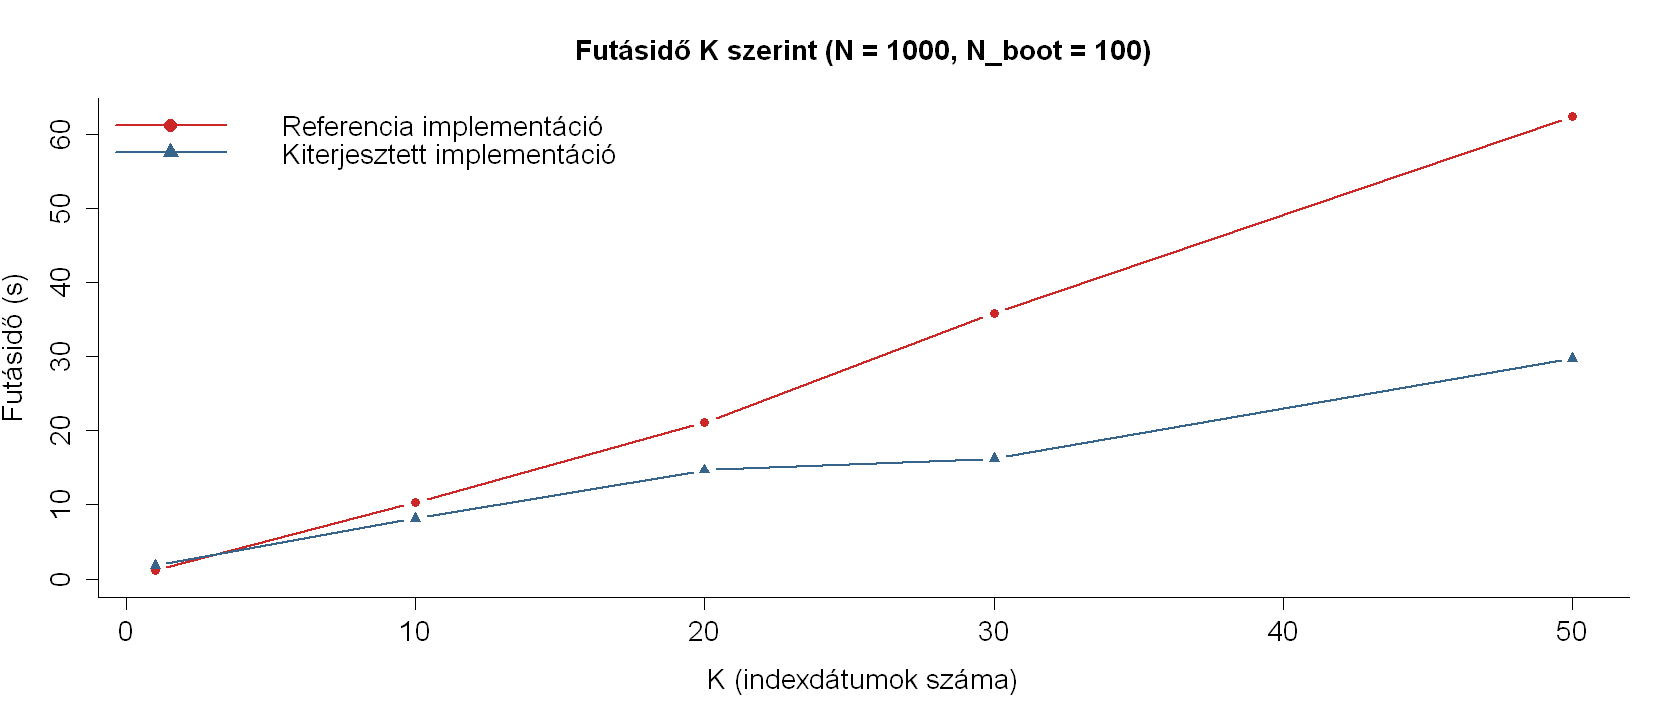

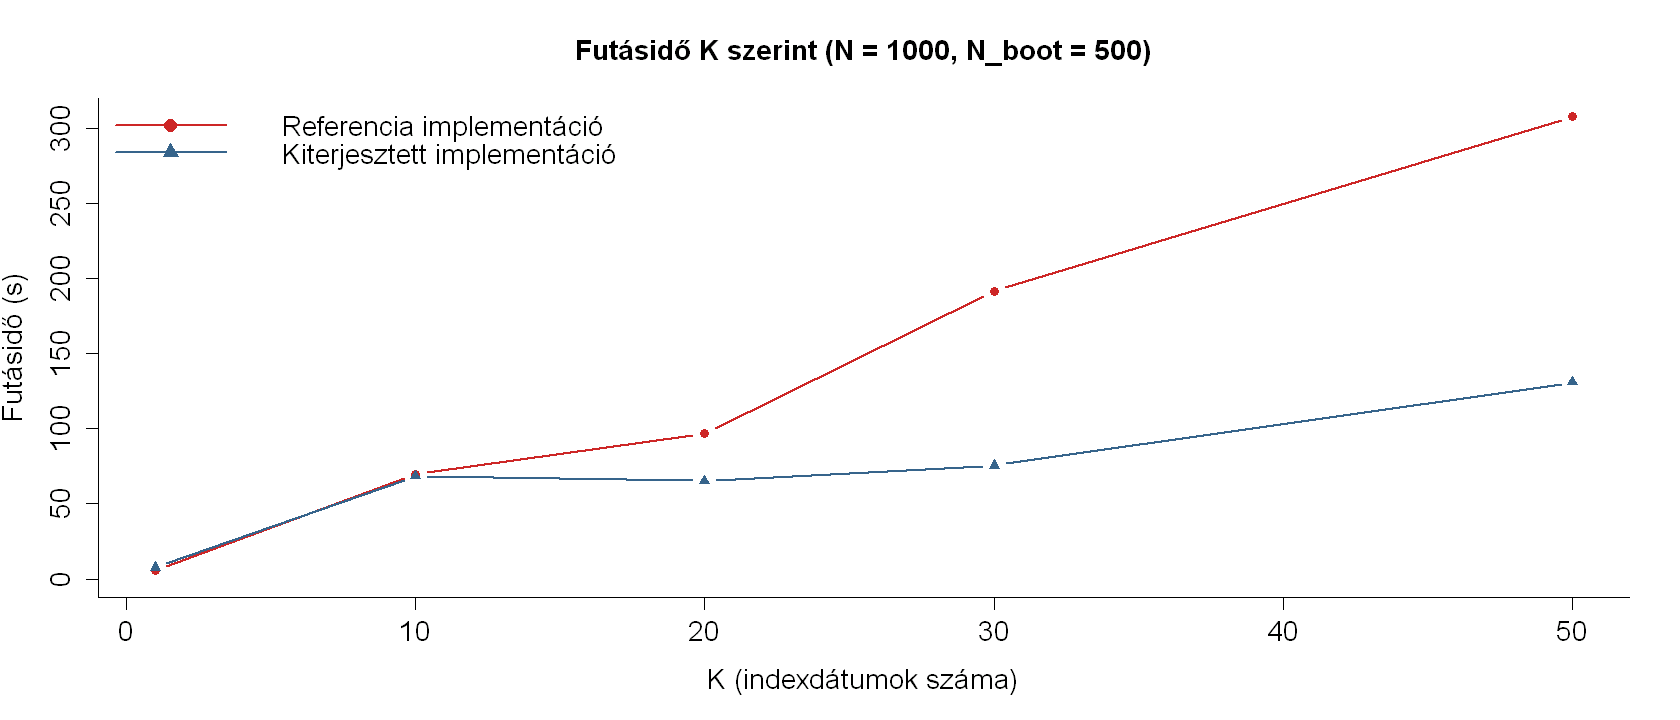

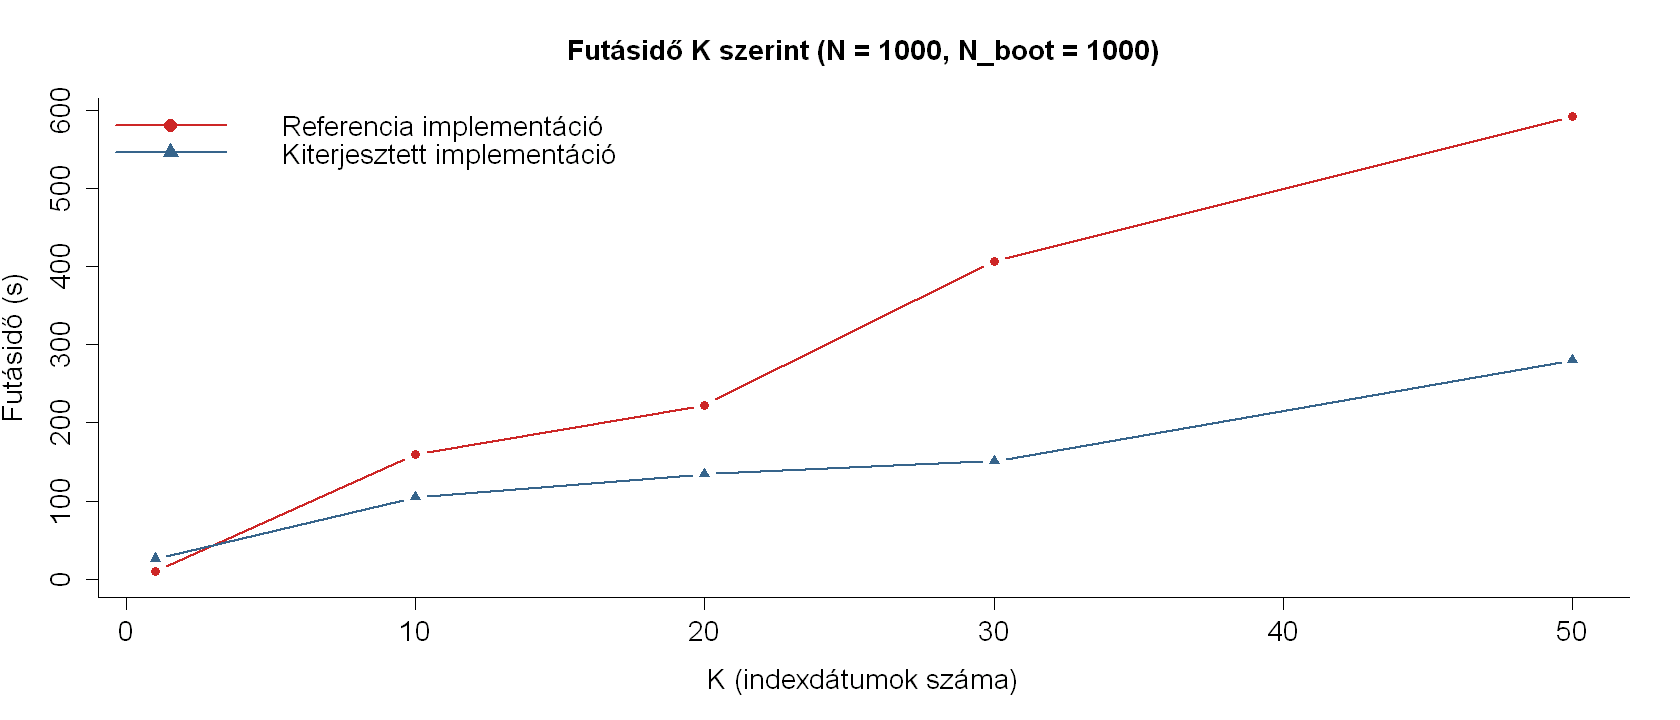

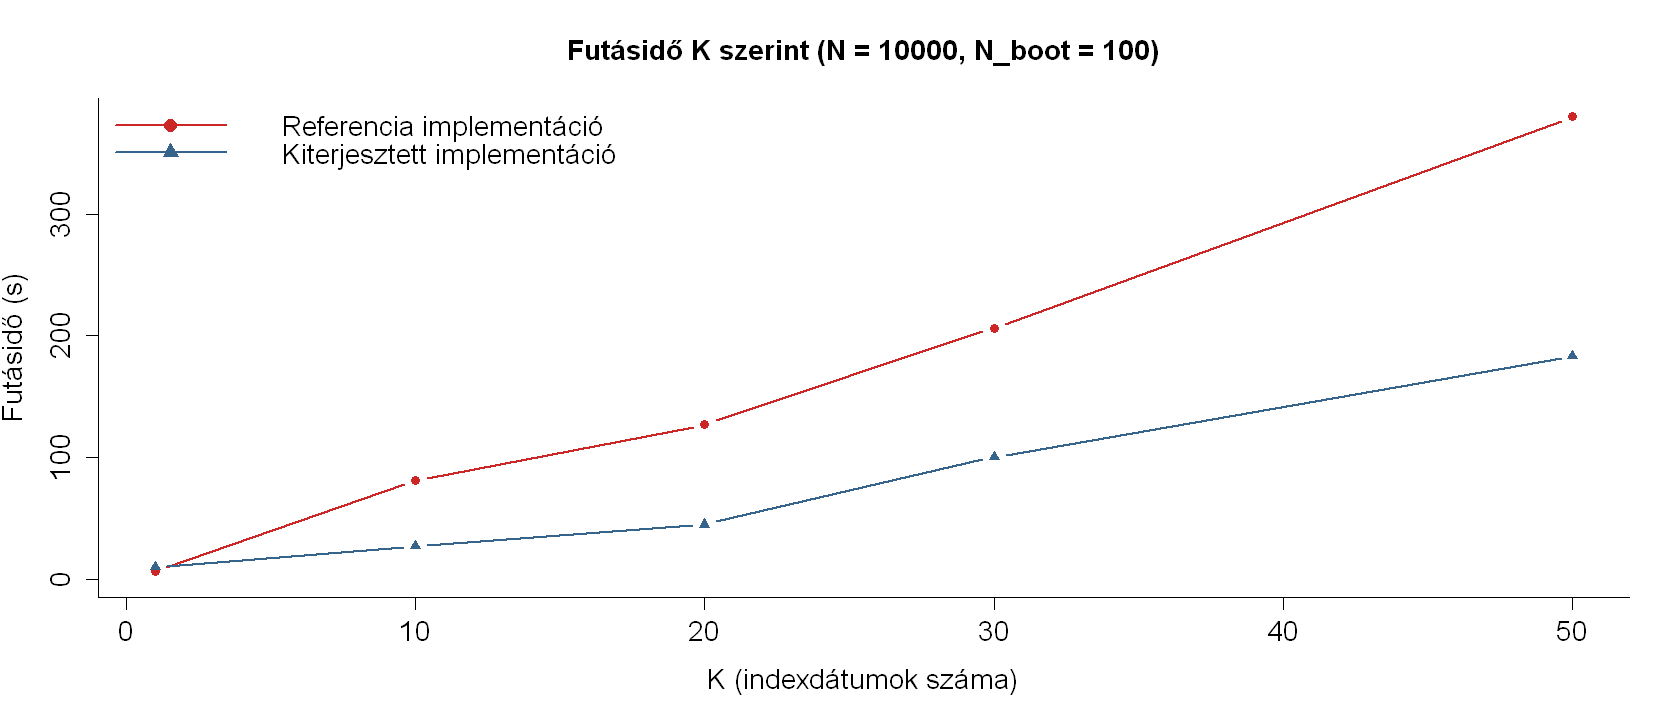

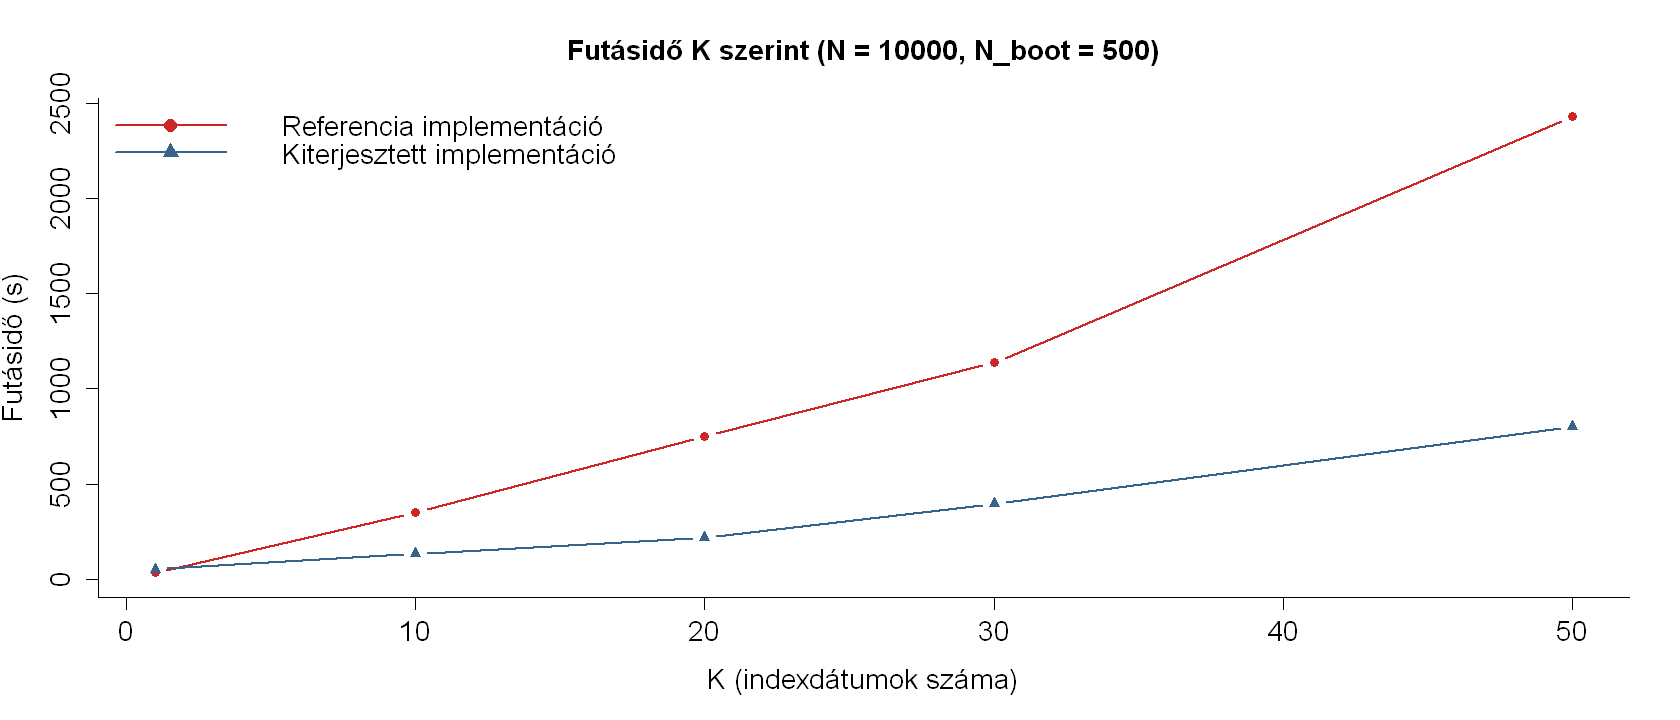

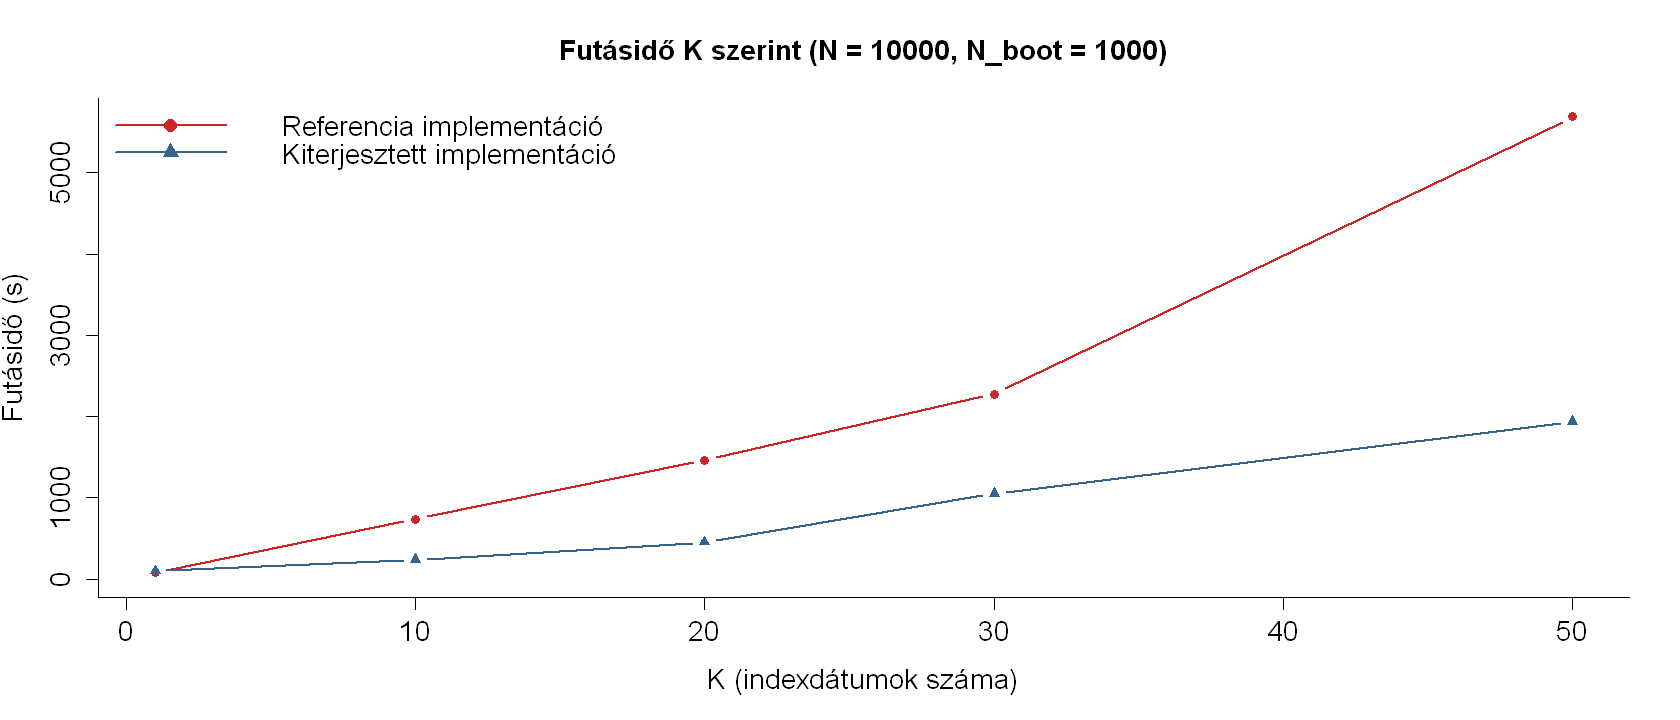

In [21]:
# Chart

options(repr.plot.width = 14, repr.plot.height = 6)
text_scale <- 1.4

stopifnot(exists("summary_runtime_disp"))

plot_dt_all <- as.data.frame(summary_runtime_disp, stringsAsFactors = FALSE)
plot_dt_all$N <- as.numeric(plot_dt_all$N)
plot_dt_all$K <- as.numeric(plot_dt_all$K)
plot_dt_all$N_boot <- as.numeric(plot_dt_all$N_boot)
plot_dt_all$elapsed_sec_mean_ref <- as.numeric(plot_dt_all$elapsed_sec_mean_ref)
plot_dt_all$elapsed_sec_mean_ext <- as.numeric(plot_dt_all$elapsed_sec_mean_ext)

plot_runtime_chart <- function(target_N, target_N_boot, plot_dt_all, text_scale = 1.4) {
  plot_dt <- plot_dt_all[
    plot_dt_all$N == target_N & plot_dt_all$N_boot == target_N_boot,
    c("K", "elapsed_sec_mean_ref", "elapsed_sec_mean_ext"),
    drop = FALSE
  ]
  plot_dt <- plot_dt[order(plot_dt$K), , drop = FALSE]

  if (!nrow(plot_dt)) {
    stop(sprintf("Nem talalhato sor N = %d es N_boot = %d ertekhez.", target_N, target_N_boot))
  }

  ylim_max <- max(c(plot_dt$elapsed_sec_mean_ref, plot_dt$elapsed_sec_mean_ext), na.rm = TRUE)

  plot(
    plot_dt$K,
    plot_dt$elapsed_sec_mean_ref,
    type = "b",
    pch = 16,
    lwd = 2,
    col = "firebrick3",
    xlab = "K (indexdátumok száma)",
    ylab = "Futásidő (s)",
    ylim = c(0, ylim_max),
    main = sprintf("Futásidő K szerint (N = %d, N_boot = %d)", target_N, target_N_boot),
    cex.main = text_scale,
    cex.lab = text_scale,
    cex.axis = text_scale,
    bty = "l"
  )

  lines(
    plot_dt$K,
    plot_dt$elapsed_sec_mean_ext,
    type = "b",
    pch = 17,
    lwd = 2,
    col = "steelblue4"
  )

  legend(
    "topleft",
    legend = c("Referencia implementáció", "Kiterjesztett implementáció"),
    col = c("firebrick3", "steelblue4"),
    pch = c(16, 17),
    lwd = 2,
    cex = text_scale,
    bty = "n"
  )
}

plot_specs <- unique(plot_dt_all[, c("N", "N_boot")])
plot_specs <- plot_specs[order(plot_specs$N, plot_specs$N_boot), , drop = FALSE]

invisible(lapply(seq_len(nrow(plot_specs)), function(i) {
  plot_runtime_chart(
    target_N = plot_specs$N[[i]],
    target_N_boot = plot_specs$N_boot[[i]],
    plot_dt_all = plot_dt_all,
    text_scale = text_scale
  )
}))